# Sprint 4 - Detección de valores anómalos en exportaciones peruanas

Este notebook analiza el valor unitario (`V.U.`) por subpartida. Cada subpartida se trata como un *slice* independiente porque puede tener una distribución propia de precios, cantidades, calidades, países, operadores y unidades físicas.

Objetivos:
- Cargar y validar la base de exportaciones.
- Limpiar campos numéricos y controlar nulos, infinitos, negativos e inconsistencias.
- Seleccionar subpartidas con mayor movimiento por cantidad de registros y FOB total.
- Aplicar IQR, z-score y LOF por subpartida.
- Calcular métricas estadísticas, coincidencias, discrepancias e intervalos de confianza.
- Identificar de 2 a 5 subpartidas problemáticas con evidencia, causa probable y plan de mitigación.

## 1. Configuración

Puedes trabajar desde SQL Server o desde un archivo local (`csv`, `xlsx`, `parquet`). Si `USAR_SQL_SERVER = True`, el notebook consulta la tabla de exportaciones. Si prefieres archivo, cambia `USAR_SQL_SERVER = False` y define `RUTA_ARCHIVO`.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

RAIZ_PROYECTO = Path.cwd().parent if Path.cwd().name.lower() == "notebook" else Path.cwd()
RUTA_OUTPUT = RAIZ_PROYECTO / "output" / "notebook_sprint4"
RUTA_OUTPUT.mkdir(parents=True, exist_ok=True)

USAR_SQL_SERVER = True
RUTA_ARCHIVO = None  # Ejemplo: RAIZ_PROYECTO / "data" / "exportaciones.xlsx"

SERVIDOR = r"DESKTOP-OGU19A7\SQLEXPRESS,56878"
BASE_DATOS = "DB_GEE_DW_ADUANAS"
TABLA_EXPORTACIONES = "[SC_ADUANA].[BASE_EXPORTACIONES]"
ANIO_INI = 2024
ANIO_FIN = 2026

TOP_SUBPARTIDAS = 20
MIN_REGISTROS_SLICE = 36
N_BOOTSTRAP = 1000
RANDOM_STATE = 42

LOF_CONTAMINATION = 0.05
LOF_N_NEIGHBORS = 20
ZSCORE_UMBRAL = 3.0
IQR_FACTOR = 1.5

np.random.seed(RANDOM_STATE)

## 2. Funciones de carga, normalización y validación

El notebook usa nombres canónicos para trabajar aunque la fuente tenga nombres distintos. Si alguna columna no existe, se crea como `NA`, salvo las columnas críticas.

In [2]:
COLUMNAS_CANDIDATAS = {
    "subpartida": ["subpartida", "num_partida", "partida_arancelaria", "cod_subpartida"],
    "vu": ["vu", "v.u.", "valor_unitario", "mto_vu_unifis", "mto_vu_peso_neto"],
    "fob": ["fob", "mto_fobdol", "valor_fob", "monto_fob"],
    "peso_neto": ["peso_neto", "cnt_peso_neto", "peso", "kg_neto"],
    "unidad_fisica": ["unidad_fisica", "cod_unifisica", "unidad", "unifis"],
    "cantidad_unidad_fisica": ["cnt_unifis", "cantidad_unidad_fisica", "cantidad", "unidades"],
    "pais": ["pais", "des_pais_destino", "cod_pais_destino", "pais_destino"],
    "operador": ["operador", "ruc_exportador", "num_ruc_exportador", "exportador", "declarante"],
    "anio": ["anio", "ano", "ann", "year"],
    "sector": ["sector", "des_sector", "cod_sector"],
}

def normalizar_nombre_columna(nombre):
    texto = str(nombre).strip().lower()
    for origen, destino in [("á", "a"), ("é", "e"), ("í", "i"), ("ó", "o"), ("ú", "u"), ("ñ", "n")]:
        texto = texto.replace(origen, destino)
    texto = texto.replace(".", "").replace(" ", "_").replace("-", "_")
    while "__" in texto:
        texto = texto.replace("__", "_")
    return texto

def cargar_desde_archivo(ruta_archivo):
    ruta = Path(ruta_archivo)
    if not ruta.exists():
        raise FileNotFoundError(f"No existe el archivo: {ruta}")
    if ruta.suffix.lower() == ".csv":
        return pd.read_csv(ruta)
    if ruta.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(ruta)
    if ruta.suffix.lower() == ".parquet":
        return pd.read_parquet(ruta)
    raise ValueError("Formato no soportado. Use csv, xlsx, xls o parquet.")

def cargar_desde_sql_server():
    import pyodbc
    conexion = pyodbc.connect(
        "DRIVER={ODBC Driver 17 for SQL Server};"
        f"SERVER={SERVIDOR};"
        f"DATABASE={BASE_DATOS};"
        "Trusted_Connection=yes;"
    )
    sql = f"""
    SELECT *
    FROM {TABLA_EXPORTACIONES}
    WHERE ANIO BETWEEN ? AND ?;
    """
    try:
        return pd.read_sql(sql, conexion, params=[ANIO_INI, ANIO_FIN])
    finally:
        conexion.close()

def estandarizar_columnas(df):
    df = df.copy()
    df.columns = [normalizar_nombre_columna(c) for c in df.columns]
    disponibles = set(df.columns)
    mapa = {}
    for canonica, candidatas in COLUMNAS_CANDIDATAS.items():
        for candidata in candidatas:
            candidata_norm = normalizar_nombre_columna(candidata)
            if candidata_norm in disponibles:
                mapa[candidata_norm] = canonica
                break
    df = df.rename(columns=mapa)
    for columna in COLUMNAS_CANDIDATAS:
        if columna not in df.columns:
            df[columna] = pd.NA
    return df

def convertir_numericos(df):
    df = df.copy()
    for columna in ["vu", "fob", "peso_neto", "cantidad_unidad_fisica", "anio"]:
        df[columna] = pd.to_numeric(df[columna], errors="coerce")
    return df

def calcular_vu_si_no_existe(df):
    df = df.copy()
    vu_vacio = df["vu"].isna().all()
    if vu_vacio and df["fob"].notna().any():
        if df["cantidad_unidad_fisica"].notna().any():
            df["vu"] = df["fob"] / df["cantidad_unidad_fisica"].replace(0, np.nan)
        elif df["peso_neto"].notna().any():
            df["vu"] = df["fob"] / df["peso_neto"].replace(0, np.nan)
    return df

def validar_y_limpiar(df):
    df = estandarizar_columnas(df)
    df = convertir_numericos(df)
    df = calcular_vu_si_no_existe(df)
    df = df.replace([np.inf, -np.inf], np.nan)
    df["subpartida"] = df["subpartida"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
    df.loc[df["subpartida"].isin(["", "nan", "None", "<NA>"]), "subpartida"] = pd.NA

    condiciones_invalidas = (
        df["subpartida"].isna()
        | df["vu"].isna()
        | (df["vu"] <= 0)
        | df["fob"].lt(0).fillna(False)
        | df["peso_neto"].lt(0).fillna(False)
        | df["cantidad_unidad_fisica"].lt(0).fillna(False)
    )
    df_limpio = df.loc[~condiciones_invalidas].copy()
    df_descartado = df.loc[condiciones_invalidas].copy()
    return df_limpio, df_descartado

def resumen_calidad_datos(df_original, df_limpio, df_descartado):
    return pd.DataFrame([
        {"concepto": "Registros originales", "valor": len(df_original)},
        {"concepto": "Registros validos", "valor": len(df_limpio)},
        {"concepto": "Registros descartados", "valor": len(df_descartado)},
        {"concepto": "Subpartidas validas", "valor": df_limpio["subpartida"].nunique()},
    ])

## 3. Carga y limpieza de datos

In [3]:
if USAR_SQL_SERVER:
    df_raw = cargar_desde_sql_server()
else:
    if RUTA_ARCHIVO is None:
        raise ValueError("Define RUTA_ARCHIVO o activa USAR_SQL_SERVER.")
    df_raw = cargar_desde_archivo(RUTA_ARCHIVO)

df, df_descartado = validar_y_limpiar(df_raw)
resumen_calidad_datos(df_raw, df, df_descartado)

,concepto,valor
0,Registros originales,574738
1,Registros validos,574738
2,Registros descartados,0
3,Subpartidas validas,813


In [4]:
columnas_principales = ["subpartida", "vu", "fob", "peso_neto", "cantidad_unidad_fisica", "unidad_fisica", "pais", "operador", "anio", "sector"]
df[columnas_principales].head()

,subpartida,vu,fob,peso_neto,cantidad_unidad_fisica,unidad_fisica,pais,operador,anio,sector
0,1005903000,2.694400,10238.72,3800.0,3800.0,KG,<NA>,<NA>,2024,<NA>
1,0710809000,5.524600,828.69,150.0,150.0,KG,<NA>,<NA>,2024,<NA>
2,2103909000,5.524559,2254.02,408.0,408.0,KG,<NA>,<NA>,2024,<NA>
3,2103909000,5.524566,1209.88,219.0,219.0,KG,<NA>,<NA>,2024,<NA>
4,2103909000,5.524545,182.31,33.0,33.0,KG,<NA>,<NA>,2024,<NA>


## 4. Selección del universo inicial de subpartidas

Se priorizan subpartidas con mayor representatividad operativa y económica: cantidad de registros y FOB total.

In [5]:
def seleccionar_subpartidas(df):
    resumen = (
        df.groupby("subpartida", dropna=False)
        .agg(
            tamano=("vu", "size"),
            fob_total=("fob", "sum"),
            vu_mediana=("vu", "median"),
            vu_media=("vu", "mean"),
        )
        .reset_index()
    )
    resumen = resumen[resumen["tamano"] >= MIN_REGISTROS_SLICE].copy()
    resumen["rank_tamano"] = resumen["tamano"].rank(ascending=False, method="min")
    resumen["rank_fob"] = resumen["fob_total"].rank(ascending=False, method="min")
    resumen["score_movimiento"] = (0.55 * resumen["rank_tamano"]) + (0.45 * resumen["rank_fob"])
    return resumen.sort_values("score_movimiento").head(TOP_SUBPARTIDAS).reset_index(drop=True)

df_universo = seleccionar_subpartidas(df)
subpartidas_objetivo = df_universo["subpartida"].tolist()
df_universo

,subpartida,tamano,fob_total,vu_mediana,vu_media,rank_tamano,rank_fob,score_movimiento
0,0806100000,56022,2.483620e+09,3.096541,3.109788,1.0,4.0,2.35
1,0810400000,35057,2.423115e+09,6.357688,6.938523,3.0,5.0,3.90
2,7108120000,21104,1.671441e+10,71745.220487,67352.469239,6.0,2.0,4.20
3,0804400000,41566,1.477159e+09,2.153354,2.191224,2.0,11.0,6.05
4,0804502000,26964,5.266831e+08,1.656893,2.084215,4.0,17.0,9.85
5,0709200000,21303,4.577716e+08,4.400000,4.542944,5.0,18.0,10.85
6,0805299000,10298,2.618626e+08,1.300000,1.327379,11.0,20.0,15.05
7,0703100000,12855,1.498279e+08,0.430000,0.419591,10.0,28.0,18.10
8,1905310000,17387,1.391242e+08,2.176874,7.363689,7.0,32.0,18.25
9,0803901100,10029,1.487401e+08,0.763506,0.770710,12.0,29.0,19.65


## 5. Métodos de detección y métricas por slice

Métodos:
- `IQR`: detecta valores fuera de `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- `z-score`: detecta valores a más de 3 desviaciones estándar.
- `LOF`: detecta anomalías por densidad local dentro de cada subpartida.

In [6]:
def intervalo_bootstrap_mediana(valores, n_bootstrap=N_BOOTSTRAP, alpha=0.05):
    valores = np.asarray(pd.Series(valores).dropna(), dtype=float)
    if len(valores) < 10:
        return np.nan, np.nan
    muestras = np.random.choice(valores, size=(n_bootstrap, len(valores)), replace=True)
    estadisticos = np.median(muestras, axis=1)
    return np.percentile(estadisticos, 100 * alpha / 2), np.percentile(estadisticos, 100 * (1 - alpha / 2))

def detectar_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - IQR_FACTOR * iqr
    lim_sup = q3 + IQR_FACTOR * iqr
    return (serie < lim_inf) | (serie > lim_sup), lim_inf, lim_sup, iqr

def detectar_zscore(serie):
    media = serie.mean()
    desviacion = serie.std(ddof=1)
    if pd.isna(desviacion) or desviacion == 0:
        return pd.Series(False, index=serie.index), pd.Series(0.0, index=serie.index)
    zscore = (serie - media) / desviacion
    return zscore.abs() > ZSCORE_UMBRAL, zscore

def detectar_lof(df_slice):
    variables = ["vu"]
    if df_slice["fob"].notna().any():
        variables.append("fob")
    if df_slice["peso_neto"].notna().any():
        variables.append("peso_neto")
    matriz = df_slice[variables].copy().replace([np.inf, -np.inf], np.nan)
    for columna in variables:
        matriz[columna] = matriz[columna].fillna(matriz[columna].median())
    if len(matriz) <= max(MIN_REGISTROS_SLICE, LOF_N_NEIGHBORS + 1):
        return pd.Series(False, index=df_slice.index)
    n_neighbors = max(2, min(LOF_N_NEIGHBORS, len(matriz) - 1))
    matriz_escalada = StandardScaler().fit_transform(matriz.to_numpy(dtype=np.float32))
    modelo = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=LOF_CONTAMINATION,
        algorithm="kd_tree",
        n_jobs=-1,
    )
    pred = modelo.fit_predict(matriz_escalada)
    return pd.Series(pred == -1, index=df_slice.index)

def calcular_heterogeneidad(df_slice, columna):
    if columna not in df_slice.columns or df_slice[columna].isna().all():
        return {"n": 0, "top_share": np.nan}
    conteos = df_slice[columna].astype(str).value_counts(dropna=True)
    if conteos.empty:
        return {"n": 0, "top_share": np.nan}
    return {"n": int(conteos.size), "top_share": float(conteos.iloc[0] / conteos.sum())}

def analizar_slice(df_slice, subpartida):
    df_slice = df_slice.copy()
    serie = df_slice["vu"].astype(float)
    flag_iqr, lim_inf_iqr, lim_sup_iqr, iqr = detectar_iqr(serie)
    flag_zscore, zscore = detectar_zscore(serie)
    flag_lof = detectar_lof(df_slice)
    coincidencias = flag_iqr.astype(int) + flag_zscore.astype(int) + flag_lof.astype(int)
    ic_inf, ic_sup = intervalo_bootstrap_mediana(serie)

    media = serie.mean()
    mediana = serie.median()
    desviacion = serie.std(ddof=1)
    cv = desviacion / media if media and not pd.isna(media) else np.nan
    p01, p05, p25, p75, p95, p99 = serie.quantile([0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).tolist()

    df_flags = df_slice.copy()
    df_flags["out_iqr"] = flag_iqr
    df_flags["out_zscore"] = flag_zscore
    df_flags["out_lof"] = flag_lof
    df_flags["coincidencias_metodos"] = coincidencias
    df_flags["zscore"] = zscore

    pais = calcular_heterogeneidad(df_slice, "pais")
    operador = calcular_heterogeneidad(df_slice, "operador")
    unidad = calcular_heterogeneidad(df_slice, "unidad_fisica")

    resumen = {
        "subpartida": subpartida,
        "tamano": len(df_slice),
        "vu_media": media,
        "vu_mediana": mediana,
        "vu_desv_std": desviacion,
        "coef_variacion": cv,
        "p01": p01,
        "p05": p05,
        "p25": p25,
        "p75": p75,
        "p95": p95,
        "p99": p99,
        "iqr": iqr,
        "iqr_lim_inf": lim_inf_iqr,
        "iqr_lim_sup": lim_sup_iqr,
        "ic_mediana_inf": ic_inf,
        "ic_mediana_sup": ic_sup,
        "out_iqr_n": int(flag_iqr.sum()),
        "out_zscore_n": int(flag_zscore.sum()),
        "out_lof_n": int(flag_lof.sum()),
        "out_iqr_pct": float(flag_iqr.mean()),
        "out_zscore_pct": float(flag_zscore.mean()),
        "out_lof_pct": float(flag_lof.mean()),
        "coincidencia_2mas_n": int((coincidencias >= 2).sum()),
        "coincidencia_3_n": int((coincidencias == 3).sum()),
        "discrepancia_n": int(((coincidencias == 1) | (coincidencias == 2)).sum()),
        "paises_n": pais["n"],
        "pais_top_share": pais["top_share"],
        "operadores_n": operador["n"],
        "operador_top_share": operador["top_share"],
        "unidades_n": unidad["n"],
        "unidad_top_share": unidad["top_share"],
    }
    return resumen, df_flags

## 6. Ejecución por subpartida seleccionada

In [7]:
resumenes = []
flags_por_subpartida = []

for subpartida in subpartidas_objetivo:
    df_slice = df[df["subpartida"] == subpartida].copy()
    if len(df_slice) < MIN_REGISTROS_SLICE:
        continue
    resumen, df_flags = analizar_slice(df_slice, subpartida)
    resumenes.append(resumen)
    flags_por_subpartida.append(df_flags)

df_resumen = pd.DataFrame(resumenes)
df_flags = pd.concat(flags_por_subpartida, ignore_index=True) if flags_por_subpartida else pd.DataFrame()
df_resumen.sort_values(["coincidencia_2mas_n", "coef_variacion"], ascending=False).head(10)

,subpartida,tamano,vu_media,vu_mediana,vu_desv_std,coef_variacion,p01,p05,p25,p75,p95,p99,iqr,iqr_lim_inf,iqr_lim_sup,ic_mediana_inf,ic_mediana_sup,out_iqr_n,out_zscore_n,out_lof_n,out_iqr_pct,out_zscore_pct,out_lof_pct,coincidencia_2mas_n,coincidencia_3_n,discrepancia_n,paises_n,pais_top_share,operadores_n,operador_top_share,unidades_n,unidad_top_share
2,7108120000,21104,67352.469239,71745.220487,18891.351675,0.280485,936.002727,26572.029845,61598.373655,78993.383020,88637.131623,94654.861468,17395.009366,35505.859607,105085.897069,71485.450903,71970.943168,1981,473,1056,0.093868,0.022413,0.050038,654,107,2642,0,NaN,0,NaN,1,1.0
0,0806100000,56022,3.109788,3.096541,1.292144,0.415509,1.098561,1.946720,2.581876,3.460672,4.482762,5.742153,0.878796,1.263682,4.778867,3.083015,3.103482,2678,207,2802,0.047803,0.003695,0.050016,383,6,5292,0,NaN,0,NaN,1,1.0
4,0804502000,26964,2.084215,1.656893,1.767691,0.848133,0.401510,0.679460,0.950000,2.653061,5.000000,6.936134,1.703061,-1.604592,5.207653,1.590909,1.750000,919,212,1349,0.034082,0.007862,0.050030,252,9,2210,0,NaN,0,NaN,1,1.0
12,6907220000,14314,4.152355,3.839996,21.849592,5.261976,0.008333,2.650000,3.300000,4.300001,6.288269,8.317124,1.000001,1.799999,5.800002,3.830002,3.840001,1465,1,716,0.102347,0.000070,0.050021,157,1,2023,0,NaN,0,NaN,1,1.0
8,1905310000,17387,7.363689,2.176874,135.155537,18.354324,0.459555,1.643894,1.906335,3.694604,7.435441,18.404025,1.788269,-0.776068,6.377006,2.156006,2.196983,1188,16,870,0.068327,0.000920,0.050037,129,16,1913,0,NaN,0,NaN,1,1.0
14,0810909000,5066,3.454244,2.712493,2.844406,0.823452,0.316500,1.041000,2.299536,3.364179,9.897097,13.250772,1.064643,0.702570,4.961144,2.685433,2.747809,799,90,254,0.157718,0.017765,0.050138,121,1,1020,0,NaN,0,NaN,1,1.0
7,0703100000,12855,0.419591,0.430000,0.171850,0.409566,0.055556,0.090000,0.330000,0.500000,0.660802,0.893987,0.170000,0.075000,0.755000,0.430000,0.430000,594,88,643,0.046208,0.006846,0.050019,121,0,1204,0,NaN,0,NaN,1,1.0
9,0803901100,10029,0.770710,0.763506,0.194339,0.252156,0.603739,0.672547,0.694598,0.790944,0.953571,1.027920,0.096346,0.550078,0.935463,0.761025,0.763506,747,47,501,0.074484,0.004686,0.049955,85,19,1172,0,NaN,0,NaN,1,1.0
10,1008509000,6470,7.257250,2.554925,354.140006,48.798098,0.010000,1.734596,2.179908,3.047000,4.493543,8.151097,0.867092,0.879270,4.347638,2.535317,2.579505,503,1,324,0.077743,0.000155,0.050077,84,1,742,0,NaN,0,NaN,1,1.0
5,0709200000,21303,4.542944,4.400000,2.097965,0.461807,1.600000,2.400000,3.437947,5.400000,7.281219,8.984210,1.962053,0.494868,8.343079,4.377697,4.400000,447,62,1066,0.020983,0.002910,0.050040,64,0,1511,0,NaN,0,NaN,1,1.0


## 7. Identificación subpartidas problemáticas

El score combina proporción de outliers, dispersión, amplitud relativa del intervalo de confianza, discrepancia entre métodos y heterogeneidad de países, operadores o unidades físicas.

In [8]:
def normalizar_serie(serie):
    serie = pd.to_numeric(serie, errors="coerce").replace([np.inf, -np.inf], np.nan)
    minimo = serie.min()
    maximo = serie.max()
    if pd.isna(minimo) or pd.isna(maximo) or maximo == minimo:
        return pd.Series(0.0, index=serie.index)
    return (serie - minimo) / (maximo - minimo)

def causa_probable(fila):
    causas = []
    if fila["unidades_n"] > 1 and (pd.isna(fila["unidad_top_share"]) or fila["unidad_top_share"] < 0.85):
        causas.append("mezcla de unidades fisicas")
    if fila["paises_n"] > 3 and (pd.isna(fila["pais_top_share"]) or fila["pais_top_share"] < 0.70):
        causas.append("mezcla de paises destino")
    if fila["operadores_n"] > 5 and (pd.isna(fila["operador_top_share"]) or fila["operador_top_share"] < 0.50):
        causas.append("alta diversidad de operadores")
    if fila["coef_variacion"] > 1.0:
        causas.append("alta dispersion natural o mezcla de calidades")
    if fila["coincidencia_3_n"] > 0:
        causas.append("casos extremos confirmados por tres metodos")
    if not causas:
        causas.append("distribucion asimetrica o umbral sensible al slice")
    return "; ".join(causas)

def plan_mitigacion(fila):
    acciones = []
    if fila["paises_n"] > 3:
        acciones.append("separar el slice por pais destino")
    if fila["operadores_n"] > 5:
        acciones.append("comparar operadores recurrentes contra operadores atipicos")
    if fila["unidades_n"] > 1:
        acciones.append("homologar o segmentar por unidad fisica")
    if fila["coef_variacion"] > 1.0:
        acciones.append("ajustar umbrales por subpartida y revisar percentiles extremos")
    if fila["out_lof_pct"] > fila["out_iqr_pct"] and fila["out_lof_pct"] > fila["out_zscore_pct"]:
        acciones.append("usar LOF como metodo principal para patrones locales")
    acciones.append("revisar manualmente registros con coincidencia de dos o mas metodos")
    return "; ".join(dict.fromkeys(acciones))

df_problemas = df_resumen.copy()
df_problemas["outlier_pct_max"] = df_problemas[["out_iqr_pct", "out_zscore_pct", "out_lof_pct"]].max(axis=1)
df_problemas["ic_amplitud_relativa"] = (df_problemas["ic_mediana_sup"] - df_problemas["ic_mediana_inf"]) / df_problemas["vu_mediana"].replace(0, np.nan)
df_problemas["discrepancia_pct"] = df_problemas["discrepancia_n"] / df_problemas["tamano"]
df_problemas["heterogeneidad_score"] = (
    normalizar_serie(df_problemas["paises_n"])
    + normalizar_serie(df_problemas["operadores_n"])
    + normalizar_serie(df_problemas["unidades_n"])
) / 3
df_problemas["score_problema"] = (
    0.30 * normalizar_serie(df_problemas["outlier_pct_max"])
    + 0.25 * normalizar_serie(df_problemas["coef_variacion"])
    + 0.20 * normalizar_serie(df_problemas["ic_amplitud_relativa"])
    + 0.15 * normalizar_serie(df_problemas["discrepancia_pct"])
    + 0.10 * df_problemas["heterogeneidad_score"].fillna(0)
)
df_problemas["causa_probable"] = df_problemas.apply(causa_probable, axis=1)
df_problemas["plan_mitigacion"] = df_problemas.apply(plan_mitigacion, axis=1)

df_problematicas = df_problemas.sort_values("score_problema", ascending=False).head(5).copy()
if len(df_problematicas) > 2:
    df_problematicas = df_problematicas.head(max(2, min(5, len(df_problematicas))))
df_problematicas[["subpartida", "tamano", "score_problema", "outlier_pct_max", "coef_variacion", "ic_amplitud_relativa", "causa_probable", "plan_mitigacion"]]

,subpartida,tamano,score_problema,outlier_pct_max,coef_variacion,ic_amplitud_relativa,causa_probable,plan_mitigacion
14,0810909000,5066,0.501356,0.157718,0.823452,0.022996,casos extremos confirmados por tres metodos,revisar manualmente registros con coincidencia...
18,2603000000,2137,0.498606,0.117454,29.371886,0.028756,alta dispersion natural o mezcla de calidades;...,ajustar umbrales por subpartida y revisar perc...
13,0811909100,4592,0.473048,0.144382,8.482793,0.012669,alta dispersion natural o mezcla de calidades,ajustar umbrales por subpartida y revisar perc...
10,1008509000,6470,0.424842,0.077743,48.798098,0.017295,alta dispersion natural o mezcla de calidades;...,ajustar umbrales por subpartida y revisar perc...
11,2309909000,4748,0.351306,0.105518,3.543329,0.036642,alta dispersion natural o mezcla de calidades,ajustar umbrales por subpartida y revisar perc...


## 8. Tablas por subpartida problemática

Cada tabla resume métrica, intervalo de confianza y tamaño del slice.

In [9]:
def tabla_metricas_subpartida(fila):
    return pd.DataFrame([
        {"metrica": "Mediana V.U.", "valor": fila["vu_mediana"], "ic_inferior": fila["ic_mediana_inf"], "ic_superior": fila["ic_mediana_sup"], "tamano_slice": fila["tamano"]},
        {"metrica": "Media V.U.", "valor": fila["vu_media"], "ic_inferior": np.nan, "ic_superior": np.nan, "tamano_slice": fila["tamano"]},
        {"metrica": "Coeficiente de variacion", "valor": fila["coef_variacion"], "ic_inferior": np.nan, "ic_superior": np.nan, "tamano_slice": fila["tamano"]},
        {"metrica": "IQR", "valor": fila["iqr"], "ic_inferior": fila["iqr_lim_inf"], "ic_superior": fila["iqr_lim_sup"], "tamano_slice": fila["tamano"]},
        {"metrica": "% outliers IQR", "valor": fila["out_iqr_pct"], "ic_inferior": np.nan, "ic_superior": np.nan, "tamano_slice": fila["tamano"]},
        {"metrica": "% outliers z-score", "valor": fila["out_zscore_pct"], "ic_inferior": np.nan, "ic_superior": np.nan, "tamano_slice": fila["tamano"]},
        {"metrica": "% outliers LOF", "valor": fila["out_lof_pct"], "ic_inferior": np.nan, "ic_superior": np.nan, "tamano_slice": fila["tamano"]},
        {"metrica": "Coincidencia 2+ metodos", "valor": fila["coincidencia_2mas_n"], "ic_inferior": np.nan, "ic_superior": np.nan, "tamano_slice": fila["tamano"]},
    ])

tablas_problematicas = {}
for _, fila in df_problematicas.iterrows():
    tablas_problematicas[fila["subpartida"]] = tabla_metricas_subpartida(fila)
    print(f"\nSubpartida {fila['subpartida']}")
    print(f"Interpretacion automatica: {fila['causa_probable']}.")
    print(f"Plan de mitigacion: {fila['plan_mitigacion']}.")
    display(tablas_problematicas[fila["subpartida"]])


Subpartida 0810909000
Interpretacion automatica: casos extremos confirmados por tres metodos.
Plan de mitigacion: revisar manualmente registros con coincidencia de dos o mas metodos.


,metrica,valor,ic_inferior,ic_superior,tamano_slice
0,Mediana V.U.,2.712493,2.685433,2.747809,5066
1,Media V.U.,3.454244,NaN,NaN,5066
2,Coeficiente de variacion,0.823452,NaN,NaN,5066
3,IQR,1.064643,0.702570,4.961144,5066
4,% outliers IQR,0.157718,NaN,NaN,5066
5,% outliers z-score,0.017765,NaN,NaN,5066
6,% outliers LOF,0.050138,NaN,NaN,5066
7,Coincidencia 2+ metodos,121.000000,NaN,NaN,5066



Subpartida 2603000000
Interpretacion automatica: alta dispersion natural o mezcla de calidades; casos extremos confirmados por tres metodos.
Plan de mitigacion: ajustar umbrales por subpartida y revisar percentiles extremos; revisar manualmente registros con coincidencia de dos o mas metodos.


,metrica,valor,ic_inferior,ic_superior,tamano_slice
0,Mediana V.U.,2.123710,2.098475,2.159544,2137
1,Media V.U.,8.928111,NaN,NaN,2137
2,Coeficiente de variacion,29.371886,NaN,NaN,2137
3,IQR,0.764093,0.573668,3.630039,2137
4,% outliers IQR,0.117454,NaN,NaN,2137
5,% outliers z-score,0.000936,NaN,NaN,2137
6,% outliers LOF,0.050070,NaN,NaN,2137
7,Coincidencia 2+ metodos,29.000000,NaN,NaN,2137



Subpartida 0811909100
Interpretacion automatica: alta dispersion natural o mezcla de calidades.
Plan de mitigacion: ajustar umbrales por subpartida y revisar percentiles extremos; revisar manualmente registros con coincidencia de dos o mas metodos.


,metrica,valor,ic_inferior,ic_superior,tamano_slice
0,Mediana V.U.,1.850001,1.846562,1.870000,4592
1,Media V.U.,2.457662,NaN,NaN,4592
2,Coeficiente de variacion,8.482793,NaN,NaN,4592
3,IQR,0.550018,0.874954,3.075028,4592
4,% outliers IQR,0.144382,NaN,NaN,4592
5,% outliers z-score,0.000436,NaN,NaN,4592
6,% outliers LOF,0.048127,NaN,NaN,4592
7,Coincidencia 2+ metodos,2.000000,NaN,NaN,4592



Subpartida 1008509000
Interpretacion automatica: alta dispersion natural o mezcla de calidades; casos extremos confirmados por tres metodos.
Plan de mitigacion: ajustar umbrales por subpartida y revisar percentiles extremos; revisar manualmente registros con coincidencia de dos o mas metodos.


,metrica,valor,ic_inferior,ic_superior,tamano_slice
0,Mediana V.U.,2.554925,2.535317,2.579505,6470
1,Media V.U.,7.257250,NaN,NaN,6470
2,Coeficiente de variacion,48.798098,NaN,NaN,6470
3,IQR,0.867092,0.879270,4.347638,6470
4,% outliers IQR,0.077743,NaN,NaN,6470
5,% outliers z-score,0.000155,NaN,NaN,6470
6,% outliers LOF,0.050077,NaN,NaN,6470
7,Coincidencia 2+ metodos,84.000000,NaN,NaN,6470



Subpartida 2309909000
Interpretacion automatica: alta dispersion natural o mezcla de calidades.
Plan de mitigacion: ajustar umbrales por subpartida y revisar percentiles extremos; revisar manualmente registros con coincidencia de dos o mas metodos.


,metrica,valor,ic_inferior,ic_superior,tamano_slice
0,Mediana V.U.,1.040000,1.013063,1.051170,4748
1,Media V.U.,2.057975,NaN,NaN,4748
2,Coeficiente de variacion,3.543329,NaN,NaN,4748
3,IQR,0.279271,0.475344,1.592427,4748
4,% outliers IQR,0.105518,NaN,NaN,4748
5,% outliers z-score,0.008635,NaN,NaN,4748
6,% outliers LOF,0.049705,NaN,NaN,4748
7,Coincidencia 2+ metodos,41.000000,NaN,NaN,4748


## 9. Gráficos comparativos por subpartida

Los gráficos muestran la distribución del V.U. y los registros detectados por dos o más métodos.

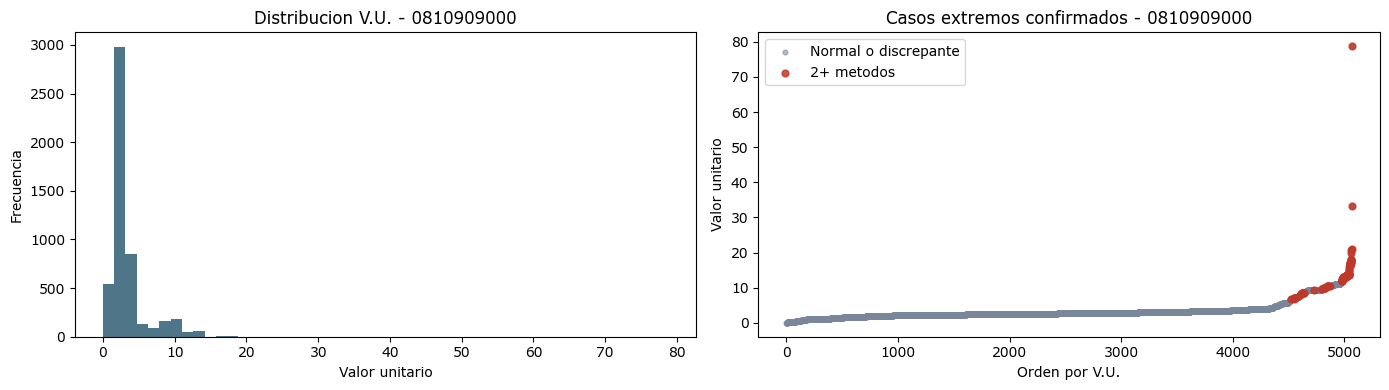

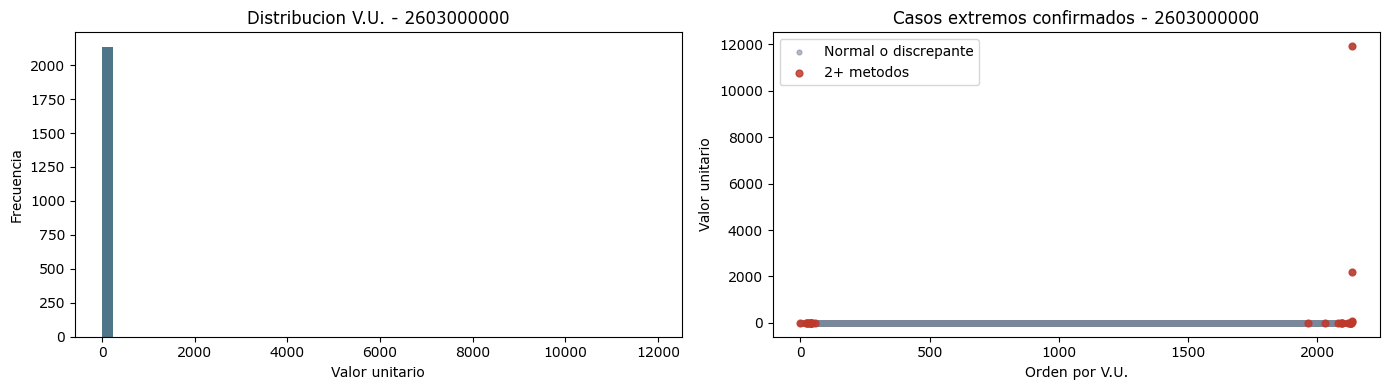

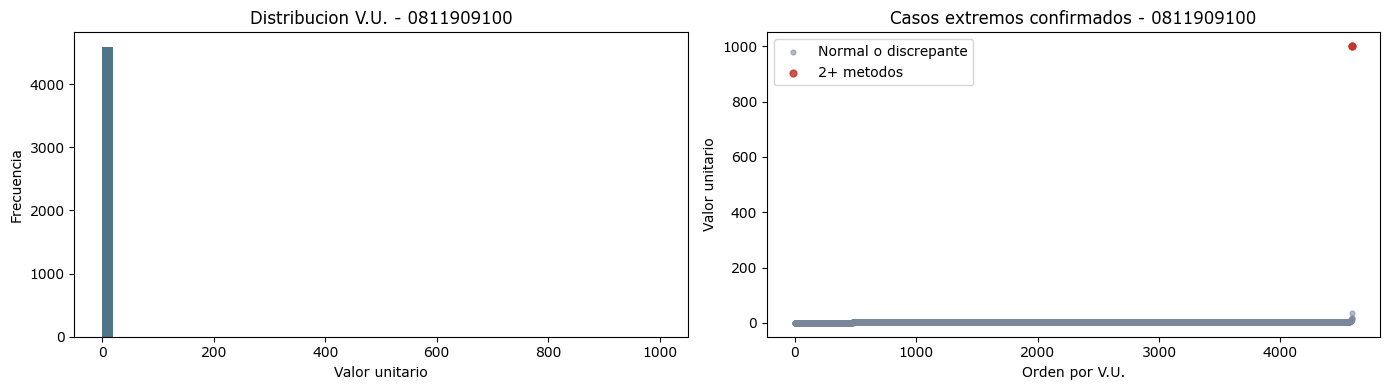

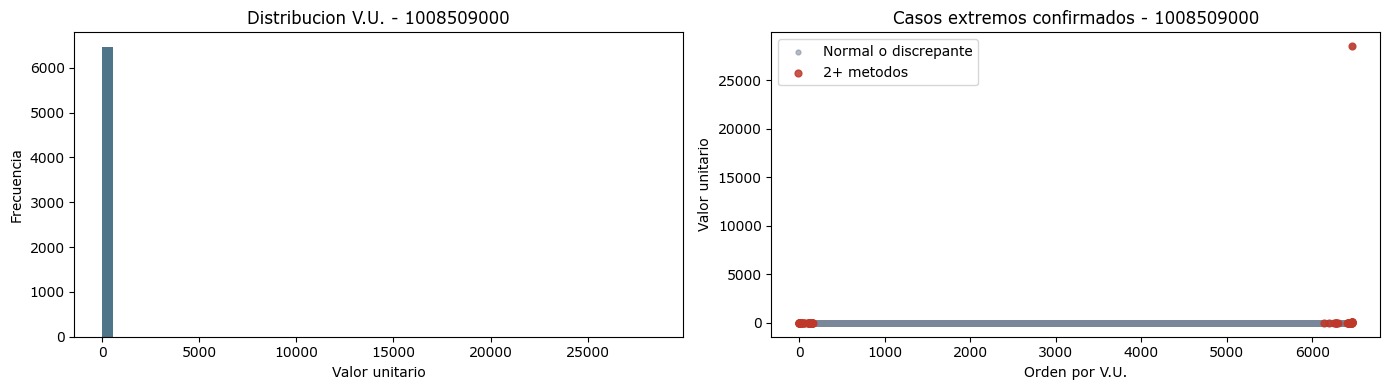

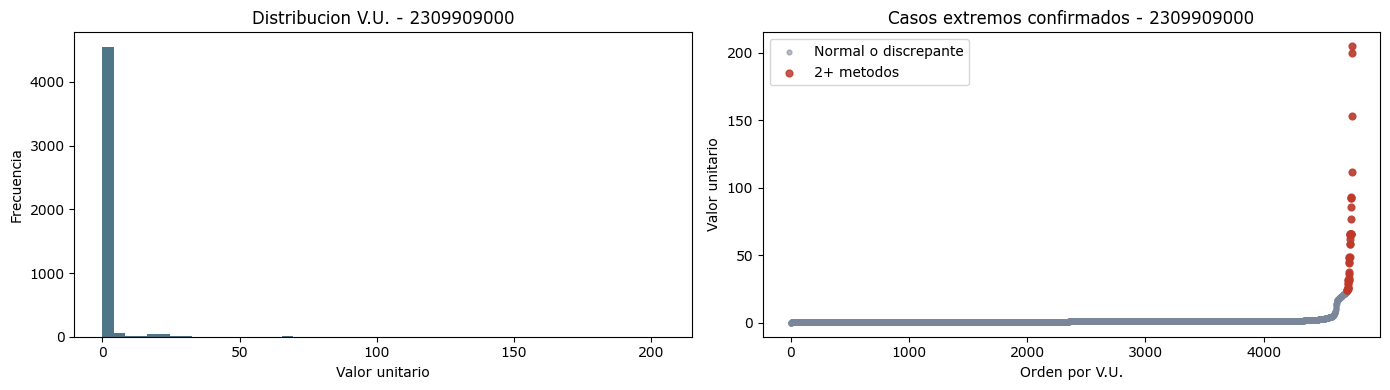

In [10]:
def graficar_subpartida(df_flags, subpartida):
    datos = df_flags[df_flags["subpartida"] == subpartida].copy()
    if datos.empty:
        return
    datos = datos.sort_values("vu").reset_index(drop=True)
    extremos = datos["coincidencias_metodos"] >= 2

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(datos["vu"], bins=50, color="#2F5D73", alpha=0.85)
    axes[0].set_title(f"Distribucion V.U. - {subpartida}")
    axes[0].set_xlabel("Valor unitario")
    axes[0].set_ylabel("Frecuencia")

    axes[1].scatter(datos.index, datos["vu"], s=12, color="#7A869A", alpha=0.55, label="Normal o discrepante")
    axes[1].scatter(datos.loc[extremos].index, datos.loc[extremos, "vu"], s=24, color="#C0392B", alpha=0.85, label="2+ metodos")
    axes[1].set_title(f"Casos extremos confirmados - {subpartida}")
    axes[1].set_xlabel("Orden por V.U.")
    axes[1].set_ylabel("Valor unitario")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

for subpartida in df_problematicas["subpartida"].tolist():
    graficar_subpartida(df_flags, subpartida)

## 10. Tabla final para presentación

Tabla lista para presentar al profesor.

In [11]:
df_final_presentacion = df_problematicas.copy()
df_final_presentacion["metrica_principal"] = df_final_presentacion.apply(
    lambda fila: f"CV={fila['coef_variacion']:.3f}; outlier max={fila['outlier_pct_max']:.2%}; score={fila['score_problema']:.3f}",
    axis=1,
)
df_final_presentacion["evidencia"] = df_final_presentacion.apply(
    lambda fila: (
        f"IQR={fila['out_iqr_pct']:.2%}, z-score={fila['out_zscore_pct']:.2%}, "
        f"LOF={fila['out_lof_pct']:.2%}, coincidencias 2+={int(fila['coincidencia_2mas_n'])}, "
        f"paises={int(fila['paises_n'])}, operadores={int(fila['operadores_n'])}, unidades={int(fila['unidades_n'])}"
    ),
    axis=1,
)

columnas_finales = [
    "subpartida",
    "tamano",
    "metrica_principal",
    "ic_mediana_inf",
    "ic_mediana_sup",
    "evidencia",
    "causa_probable",
    "plan_mitigacion",
]

df_final_presentacion = df_final_presentacion[columnas_finales].rename(columns={
    "ic_mediana_inf": "IC inferior",
    "ic_mediana_sup": "IC superior",
    "causa_probable": "causa probable",
    "plan_mitigacion": "plan de mitigacion",
})

ruta_excel = RUTA_OUTPUT / "sprint4_tabla_final_subpartidas_problematicas.xlsx"
ruta_csv = RUTA_OUTPUT / "sprint4_tabla_final_subpartidas_problematicas.csv"
df_final_presentacion.to_excel(ruta_excel, index=False)
df_final_presentacion.to_csv(ruta_csv, index=False, encoding="utf-8-sig")

print(f"Excel generado: {ruta_excel}")
print(f"CSV generado: {ruta_csv}")
df_final_presentacion

Excel generado: c:\Users\hp\Downloads\PROYECTO_MAESTRIA\output\notebook_sprint4\sprint4_tabla_final_subpartidas_problematicas.xlsx
CSV generado: c:\Users\hp\Downloads\PROYECTO_MAESTRIA\output\notebook_sprint4\sprint4_tabla_final_subpartidas_problematicas.csv


,subpartida,tamano,metrica_principal,IC inferior,IC superior,evidencia,causa probable,plan de mitigacion
14,0810909000,5066,CV=0.823; outlier max=15.77%; score=0.501,2.685433,2.747809,"IQR=15.77%, z-score=1.78%, LOF=5.01%, coincide...",casos extremos confirmados por tres metodos,revisar manualmente registros con coincidencia...
18,2603000000,2137,CV=29.372; outlier max=11.75%; score=0.499,2.098475,2.159544,"IQR=11.75%, z-score=0.09%, LOF=5.01%, coincide...",alta dispersion natural o mezcla de calidades;...,ajustar umbrales por subpartida y revisar perc...
13,0811909100,4592,CV=8.483; outlier max=14.44%; score=0.473,1.846562,1.870000,"IQR=14.44%, z-score=0.04%, LOF=4.81%, coincide...",alta dispersion natural o mezcla de calidades,ajustar umbrales por subpartida y revisar perc...
10,1008509000,6470,CV=48.798; outlier max=7.77%; score=0.425,2.535317,2.579505,"IQR=7.77%, z-score=0.02%, LOF=5.01%, coinciden...",alta dispersion natural o mezcla de calidades;...,ajustar umbrales por subpartida y revisar perc...
11,2309909000,4748,CV=3.543; outlier max=10.55%; score=0.351,1.013063,1.051170,"IQR=10.55%, z-score=0.86%, LOF=4.97%, coincide...",alta dispersion natural o mezcla de calidades,ajustar umbrales por subpartida y revisar perc...


## 11. Exportación de resultados completos

Además de la tabla final, se exporta el resumen por subpartida y la base con flags de outliers.

In [12]:
df_resumen.to_excel(RUTA_OUTPUT / "sprint4_resumen_metricas_por_subpartida.xlsx", index=False)
df_flags.to_csv(RUTA_OUTPUT / "sprint4_flags_outliers_por_registro.csv", index=False, encoding="utf-8-sig")

print("Archivos generados en:", RUTA_OUTPUT)

Archivos generados en: c:\Users\hp\Downloads\PROYECTO_MAESTRIA\output\notebook_sprint4
